# Performance by shape

Does segmentation quality depend on what the ground-truth cells in an image look like? Each image is placed in a LOW /
MEDIUM / HIGH tertile of a GT shape property (mean over the image's GT cells, tertiles over all 250 images pooled), and
the models' scores are compared across tertiles. Qualitative: no statistical tests. Max-Projection, 7 models.
Scores and GT shapes come from `results/all_runs.csv` (`validation/consolidate.py`).

In [1]:
import sys
from pathlib import Path

BENCH_DIR = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if p.name == "bench")
sys.path.insert(0, str(BENCH_DIR))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import spearmanr

from validation.consolidate import load

matplotlib.rcParams["pdf.fonttype"] = 42
EXPORT_DIR = BENCH_DIR / "figures" / "export"

MODEL_ORDER = ["Cellpose", "InstanSeg", "Stardist", "Mesmer", "Dist U-Net", "Cellpose-SAM", "MicroSAM"]
SHAPES = ["Area", "# Cells", "Solidity", "Eccentricity", "Compactness"]  # GT shape properties
SCORE_METRICS = ["F1", "mIoU", "PQ"]
TERTILES = ["LOW", "MEDIUM", "HIGH"]
TERTILE_COLOR = {"LOW": "#FF0000", "MEDIUM": "#FFA500", "HIGH": "#00BFFF"}

## Load

In [2]:
scores = load()  # one row per test image of every run, incl. the shape of each image's GT (GT_* columns)
scores = scores[(scores["Modality"] == "MaxProj") & (scores["Arm"] == "selected") & scores["Model"].isin(MODEL_ORDER)].copy()
assert scores.groupby("Model")["ID"].apply(frozenset).nunique() == 1, "models were scored on different images"

# Tertile of each image's GT shape, over the 250 unique images
images = scores.drop_duplicates("ID").set_index("ID")
for shape in SHAPES:
    scores[f"{shape}_tertile"] = scores["ID"].map(pd.qcut(images[f"GT_{shape}"], q=3, labels=TERTILES))
scores[["Model", "Dataset", "ID", "F1", "GT_Area", "Area_tertile"]].head()

,Model,Dataset,ID,F1,GT_Area,Area_tertile
0,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,0.597849,410.915789,MEDIUM
1,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,0.427289,315.340237,MEDIUM
2,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,0.482759,342.800000,MEDIUM
3,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,0.603581,514.995283,MEDIUM
4,Dist U-Net,Vectra,/home/benjaminba/Documents/Project_data/Multip...,0.473600,327.926509,MEDIUM


## Boxplots by tertile

Score per model, split by the GT shape tertile of the image. One figure per score and shape, then the same panels
stacked into one figure per score.

In [3]:
def plot_stratified_box(ax, metric, shape):
    x = np.arange(len(MODEL_ORDER))
    width = 0.25
    rng = np.random.default_rng(0)
    for i, tertile in enumerate(TERTILES):
        offsets = x + (i - 1) * width
        data = [scores.loc[(scores["Model"] == m) & (scores[f"{shape}_tertile"] == tertile), metric] for m in MODEL_ORDER]
        bp = ax.boxplot(data, positions=offsets, widths=width * 0.9, patch_artist=True, showfliers=False,
                        medianprops=dict(color="black"))
        for patch in bp["boxes"]:
            patch.set(facecolor=TERTILE_COLOR[tertile], alpha=0.75)
        for xi, vals in zip(offsets, data):  # every image as a dot
            ax.scatter(xi + rng.uniform(-width * 0.35, width * 0.35, size=len(vals)), vals, color="black", s=0.5, alpha=0.4, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=20)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)


for metric in SCORE_METRICS:
    for shape in SHAPES:
        fig, ax = plt.subplots(figsize=(12, 5))
        plot_stratified_box(ax, metric, shape)
        ax.legend(handles=[Patch(facecolor=TERTILE_COLOR[t], label=f"{t} {shape}") for t in TERTILES],
                  loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
        ax.set_title(f"{metric} by model, stratified by GT {shape} tertile")
        fig.tight_layout()
        fig.savefig(EXPORT_DIR / f"Stratified_{metric}_{shape}.pdf", bbox_inches="tight")
        plt.close(fig)

In [4]:
for metric in SCORE_METRICS:
    fig, axs = plt.subplots(len(SHAPES), 1, figsize=(11, 2.7 * len(SHAPES)), sharex=True, sharey=True)
    for ax, shape in zip(axs, SHAPES):
        plot_stratified_box(ax, metric, shape)
        ax.set_title(f"GT {shape} tertile", fontsize=10, loc="left", pad=3)
        ax.set_ylabel("")
    axs[len(SHAPES) // 2].set_ylabel(metric)
    axs[0].legend(handles=[Patch(facecolor=TERTILE_COLOR[t], label=t) for t in TERTILES],
                  loc="lower center", bbox_to_anchor=(0.5, 1.18), ncol=3, frameon=False, fontsize=9)
    fig.suptitle(f"{metric} by model, stratified by GT shape tertile", fontsize=13)
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / f"Stratified_{metric}_AllShapes.pdf", bbox_inches="tight")
    plt.close(fig)

## Correlation heatmaps

Spearman correlation between each model's per-image score and the GT shape property, all datasets pooled.

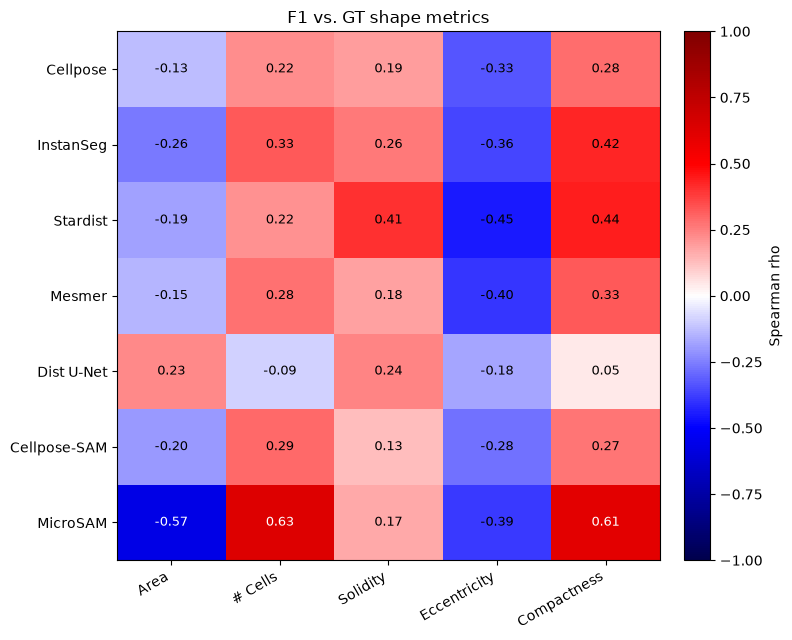

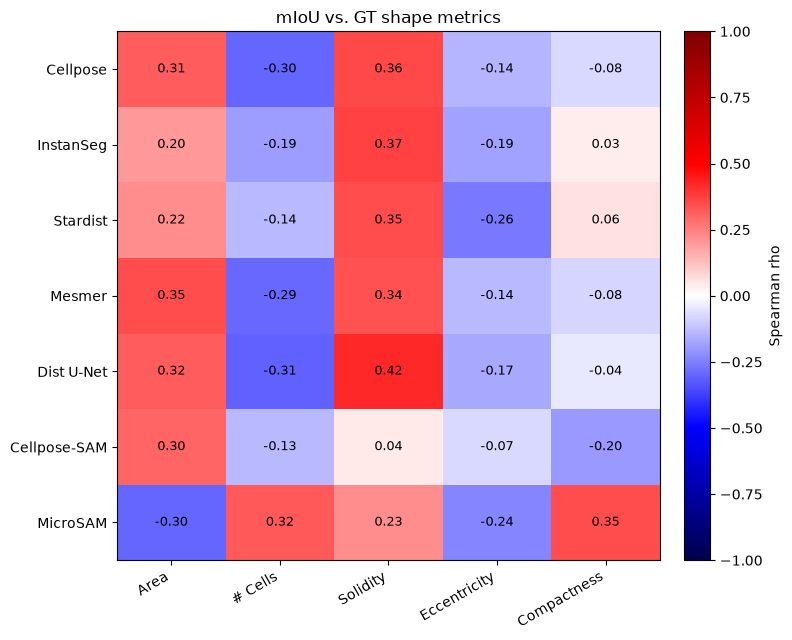

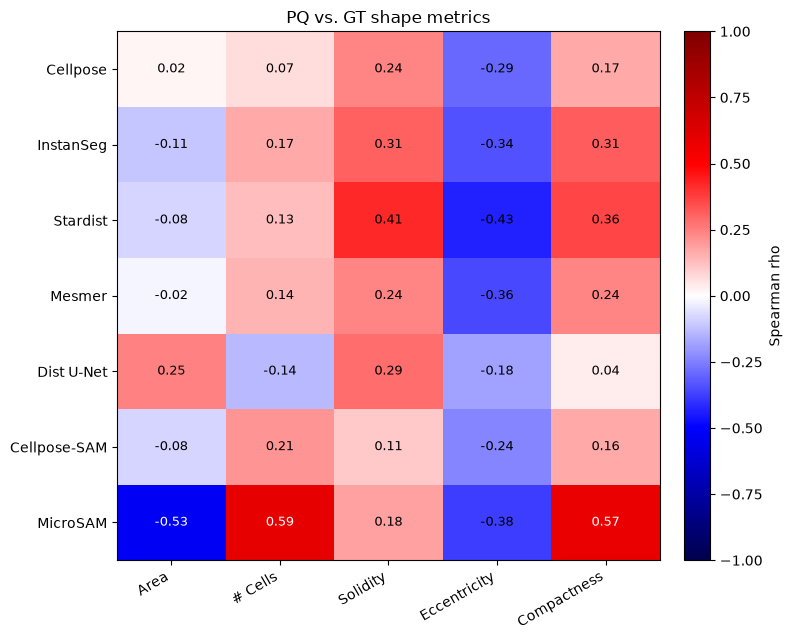

In [6]:
for metric in SCORE_METRICS:
    rho = pd.DataFrame(
        {shape: [spearmanr(scores.loc[scores["Model"] == m, f"GT_{shape}"], scores.loc[scores["Model"] == m, metric])[0]
                 for m in MODEL_ORDER] for shape in SHAPES},
        index=MODEL_ORDER,
    )

    fig, ax = plt.subplots(figsize=(8, 6.5))
    im = ax.imshow(rho, cmap="seismic", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(SHAPES))); ax.set_xticklabels(SHAPES, rotation=30, ha="right")
    ax.set_yticks(range(len(MODEL_ORDER))); ax.set_yticklabels(MODEL_ORDER)
    for i, model in enumerate(MODEL_ORDER):
        for j, shape in enumerate(SHAPES):
            ax.text(j, i, f"{rho.loc[model, shape]:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(rho.loc[model, shape]) > 0.5 else "black")
    fig.colorbar(im, ax=ax, label="Spearman rho", fraction=0.046, pad=0.04)
    ax.set_title(f"{metric} vs. GT shape metrics")
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / f"ShapeCorrelation_{metric}.pdf", bbox_inches="tight")
